
테스트 파일 처리 중: test_looking_3loop_l01.csv
12/12 [==============================] - 1s 9ms/step


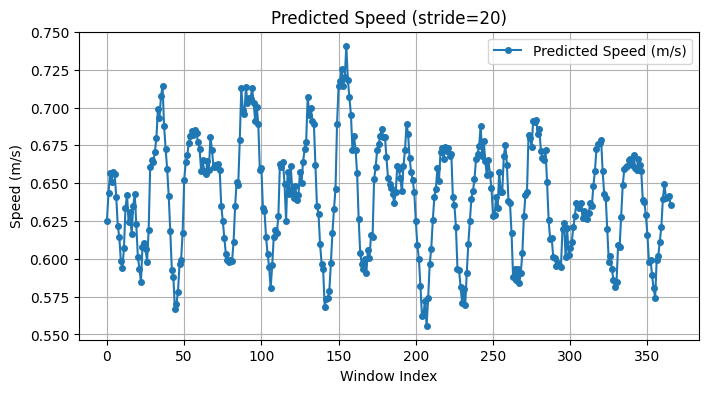

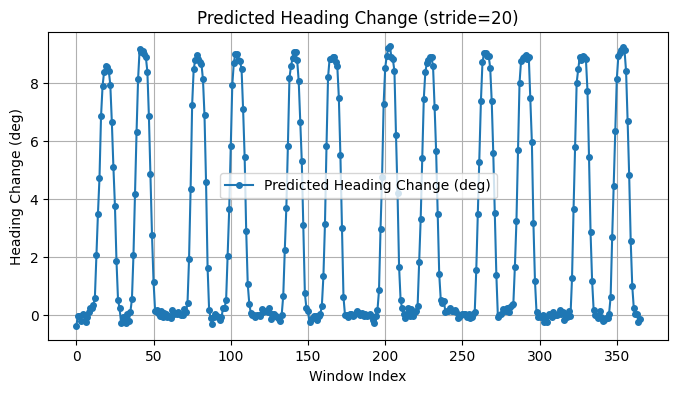

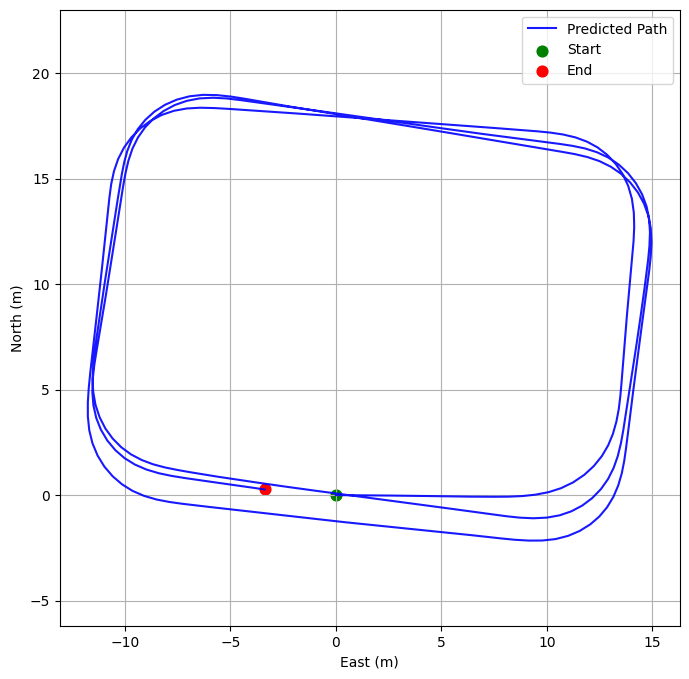

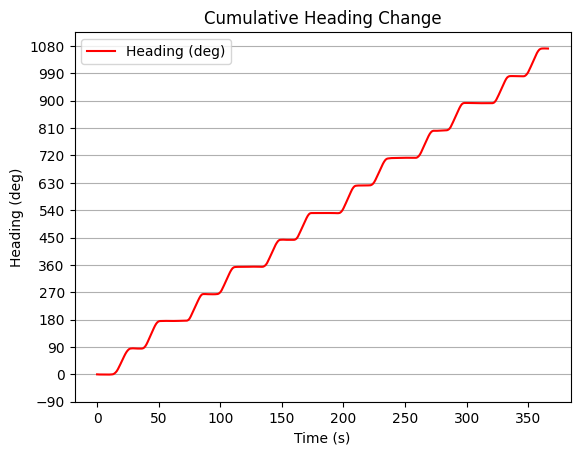


테스트 파일 처리 중: test_looking_3loop_l02.csv
12/12 [==============================] - 0s 8ms/step


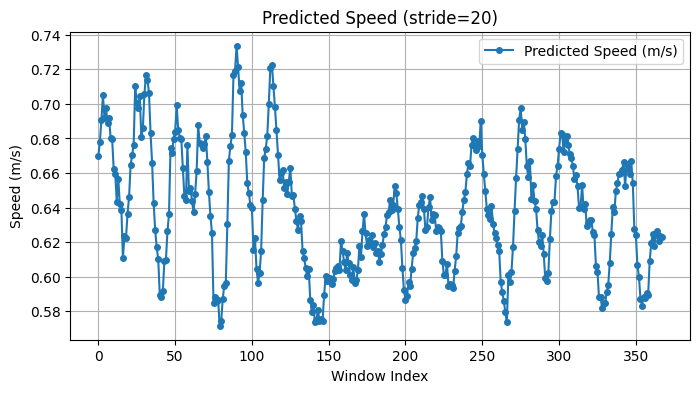

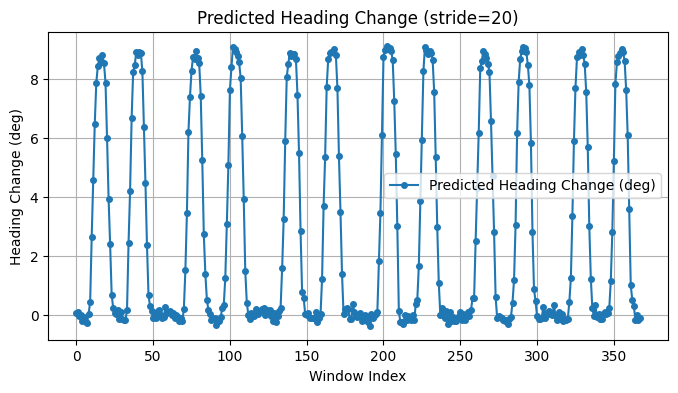

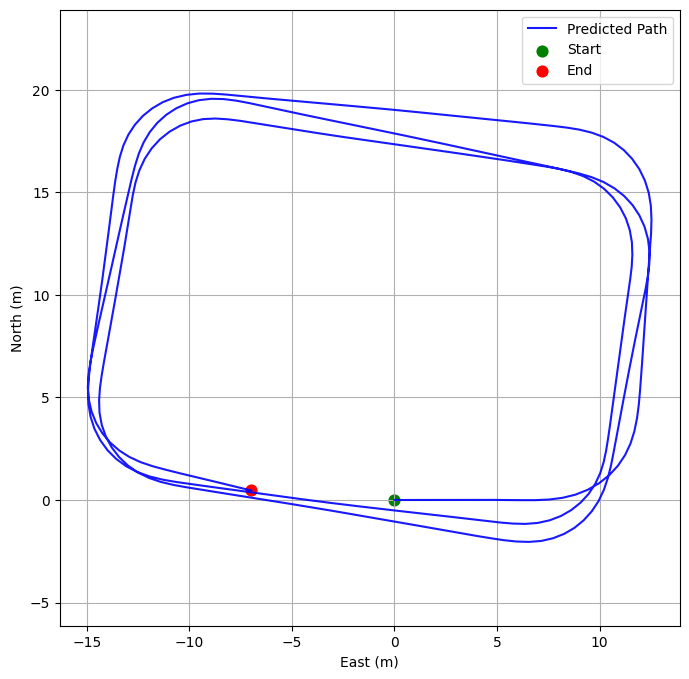

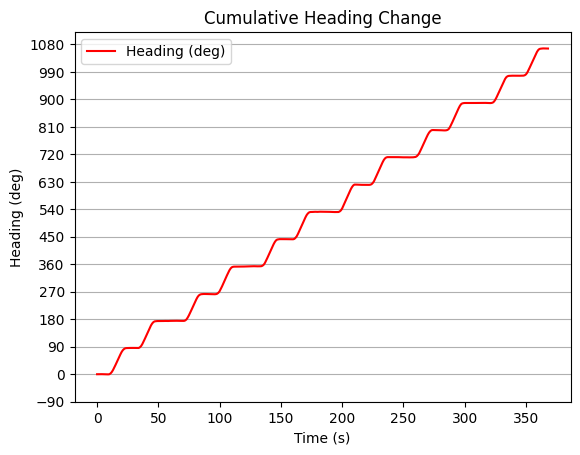


테스트 파일 처리 중: test_looking_3loop_l03.csv
12/12 [==============================] - 0s 8ms/step


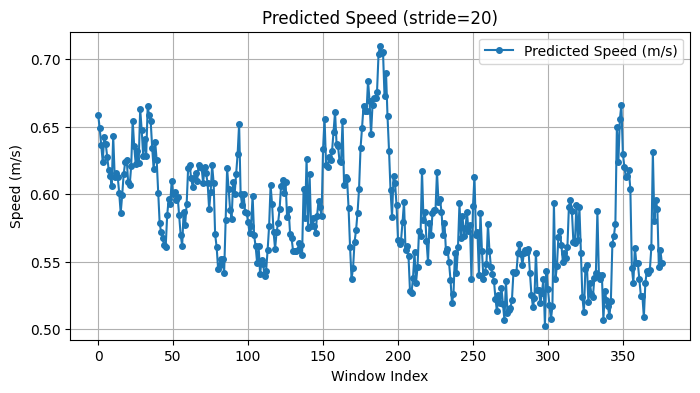

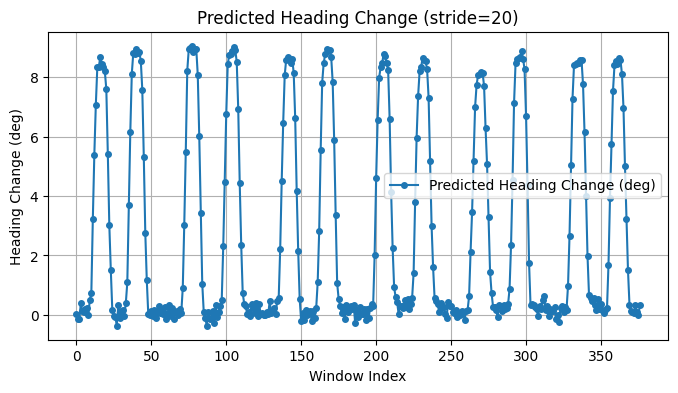

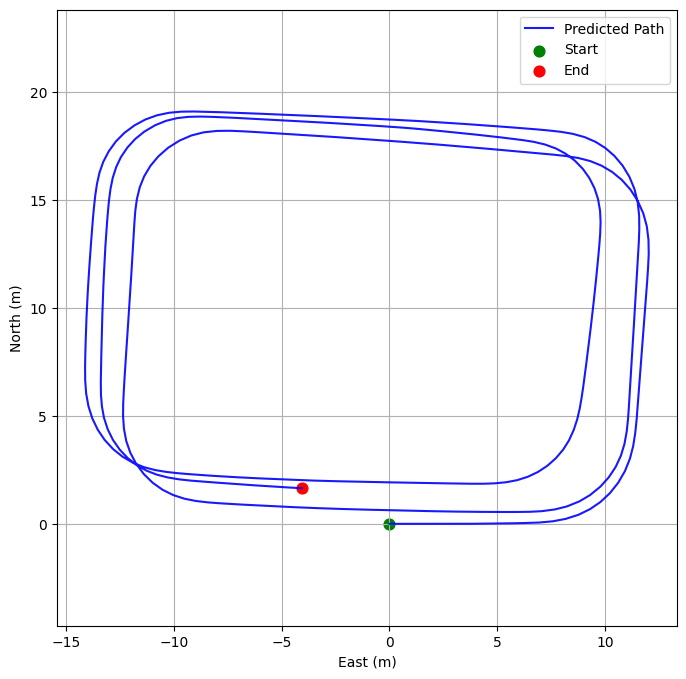

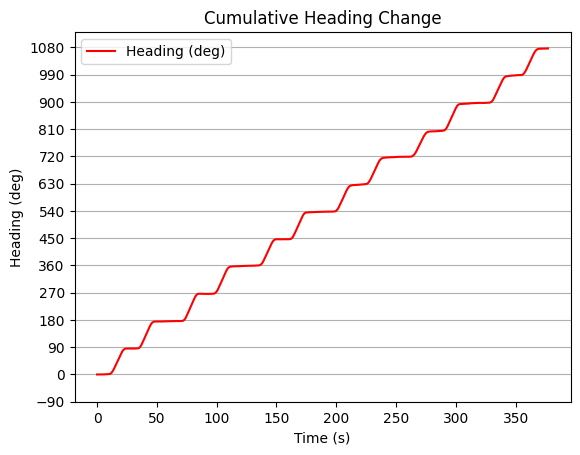


테스트 파일 처리 중: test_looking_3loop_r01.csv
12/12 [==============================] - 0s 8ms/step


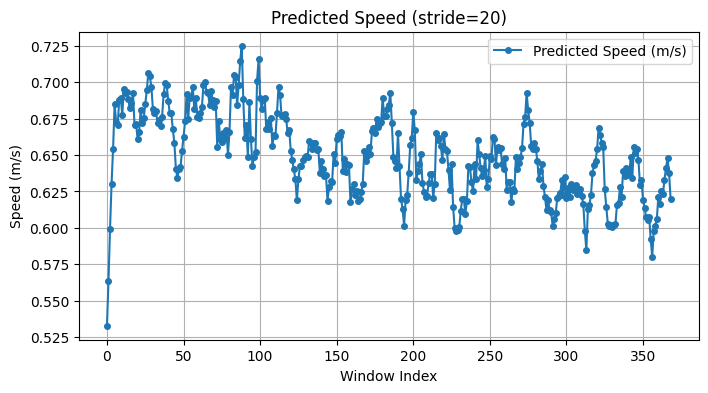

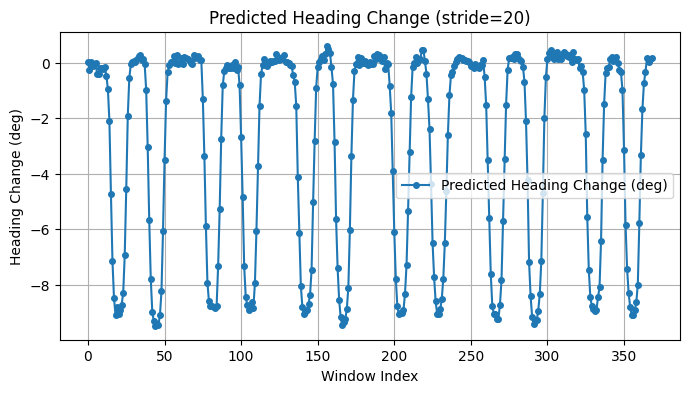

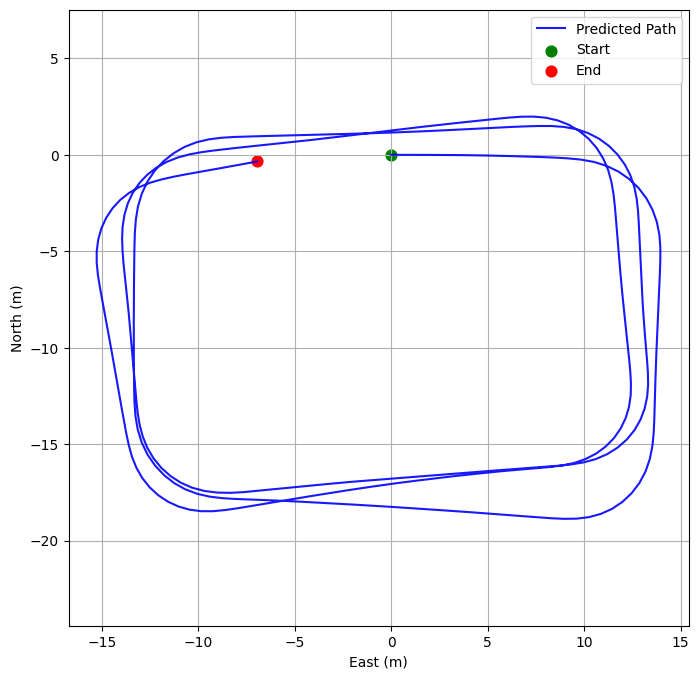

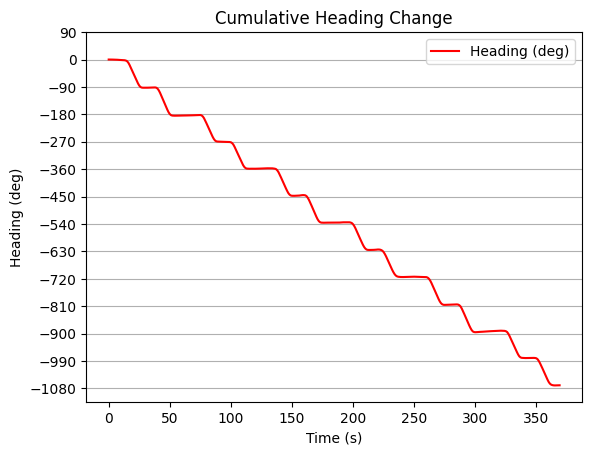


테스트 파일 처리 중: test_looking_3loop_r02.csv
13/13 [==============================] - 0s 7ms/step


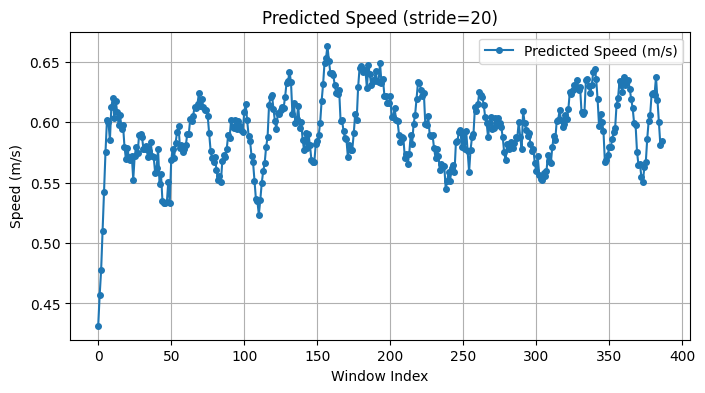

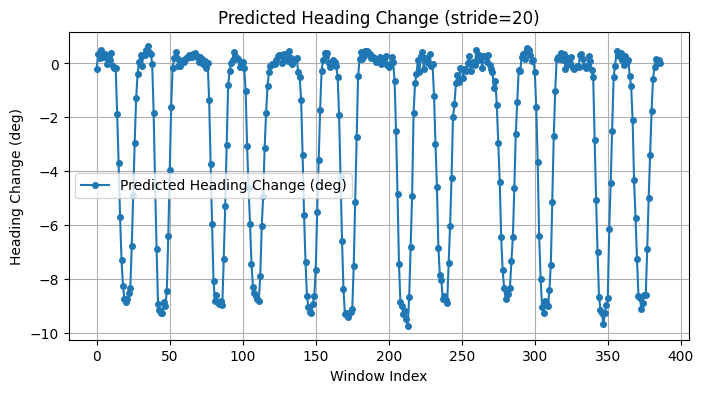

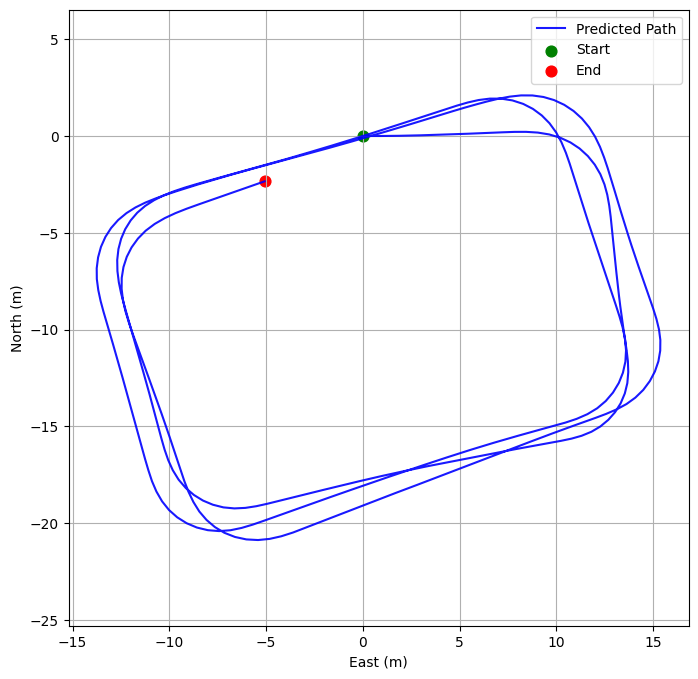

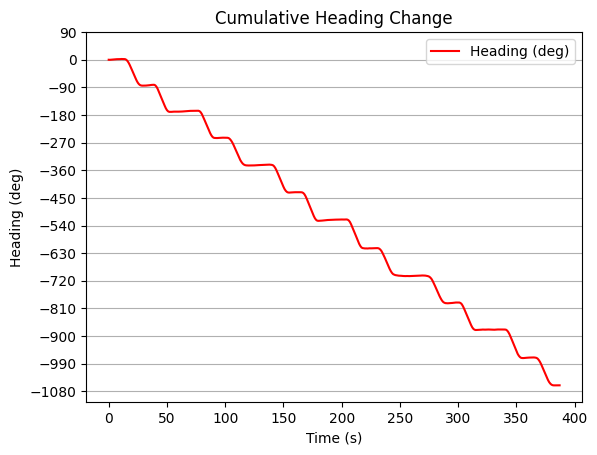


테스트 파일 처리 중: test_looking_3loop_r03.csv
12/12 [==============================] - 0s 9ms/step


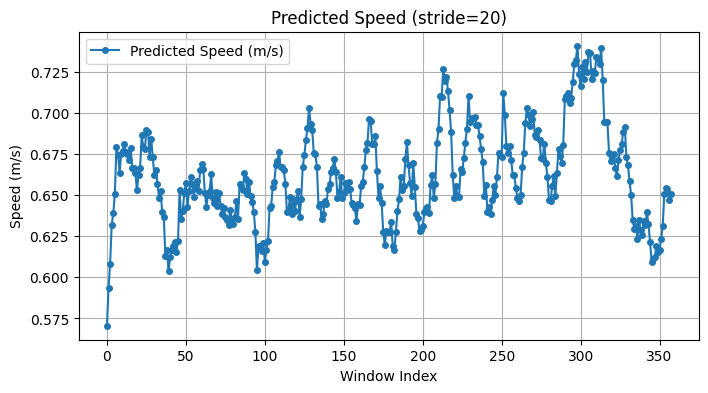

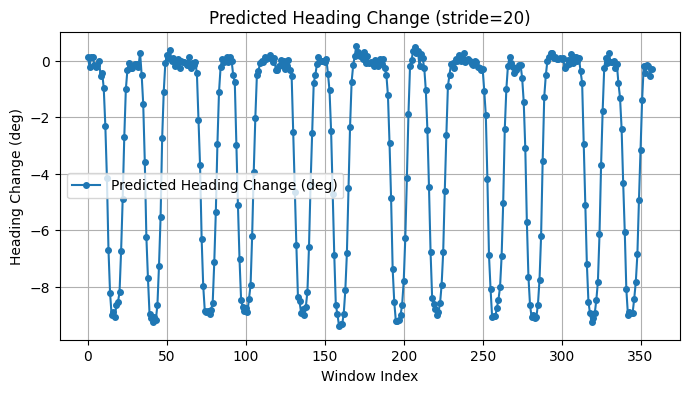

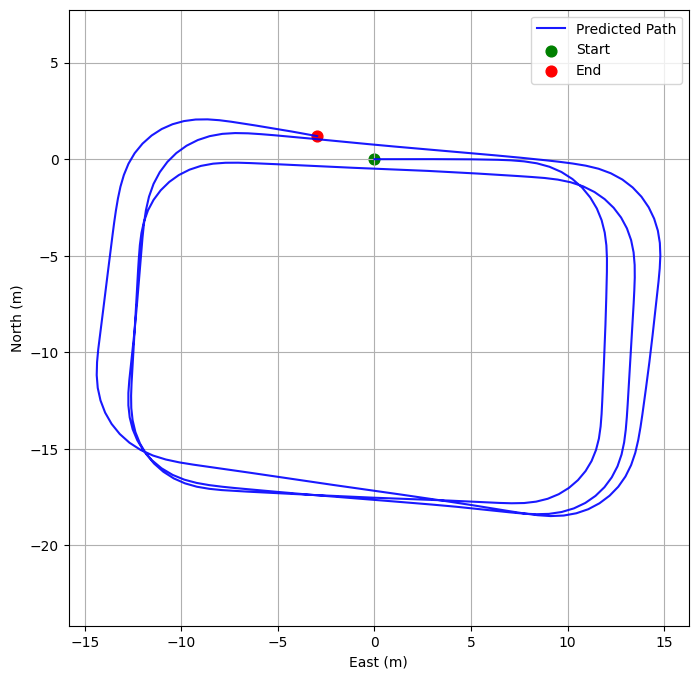

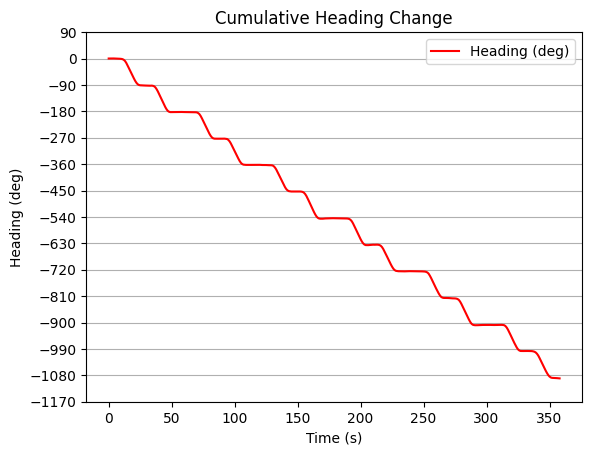


테스트 파일 처리 중: test_looking_3loop_r04.csv
12/12 [==============================] - 0s 7ms/step


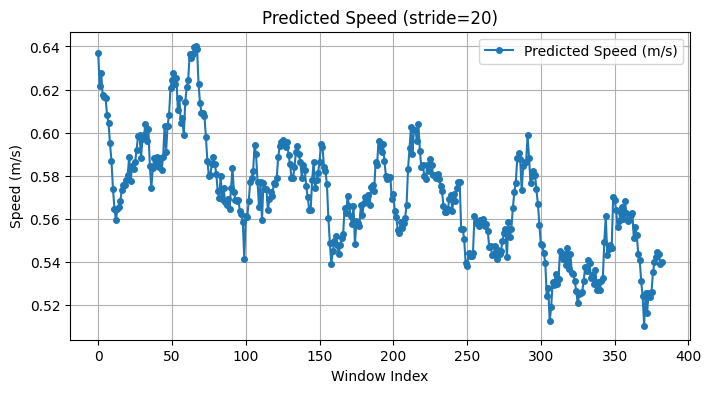

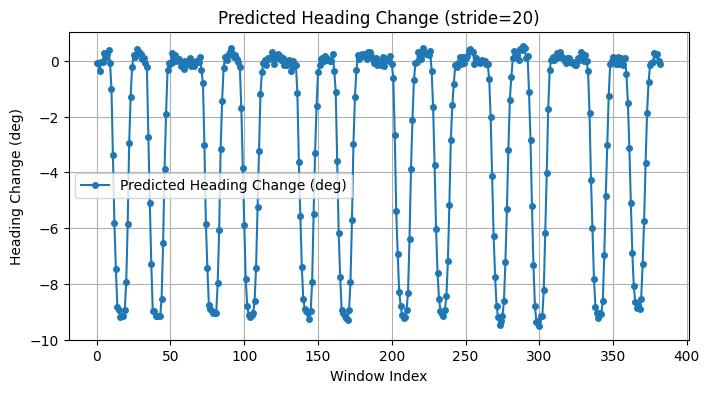

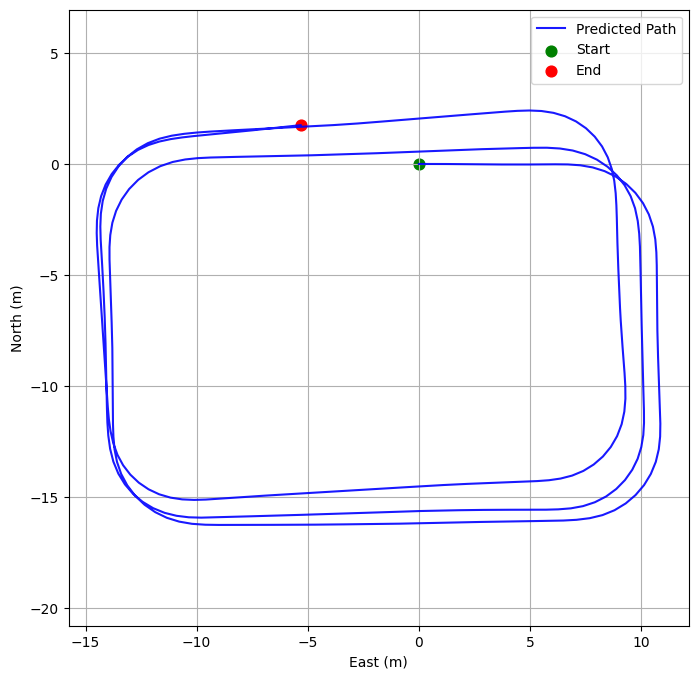

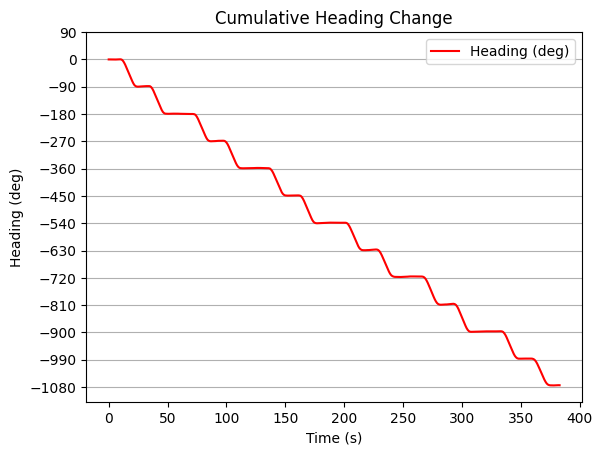


테스트 파일 처리 중: test2_looking_01.csv
16/16 [==============================] - 0s 8ms/step


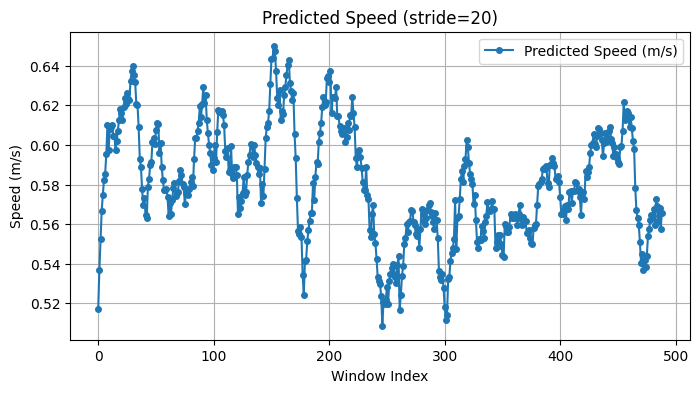

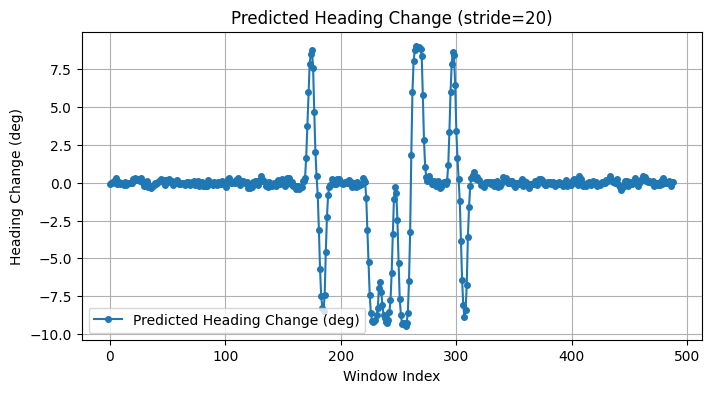

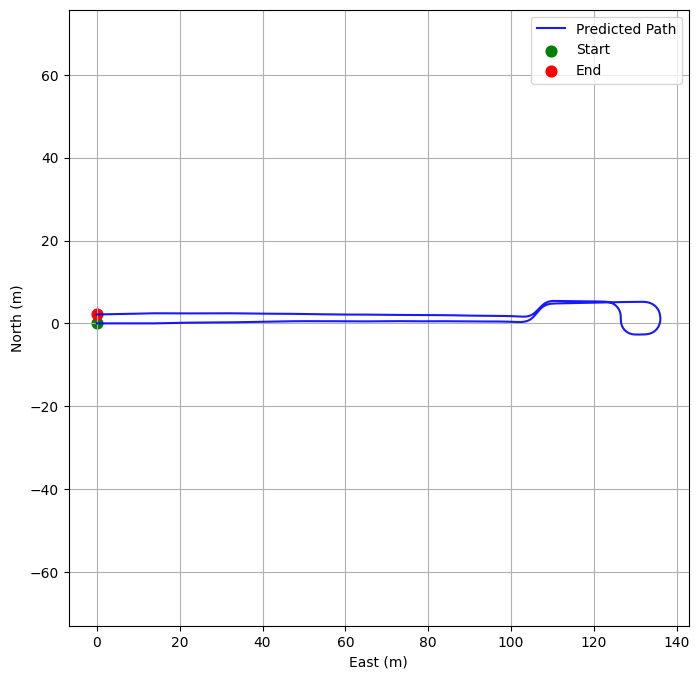

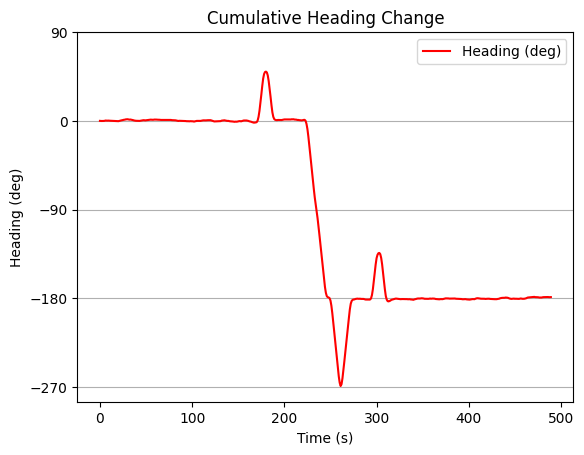


테스트 파일 처리 중: test2_looking_01_20+.csv
16/16 [==============================] - 0s 7ms/step


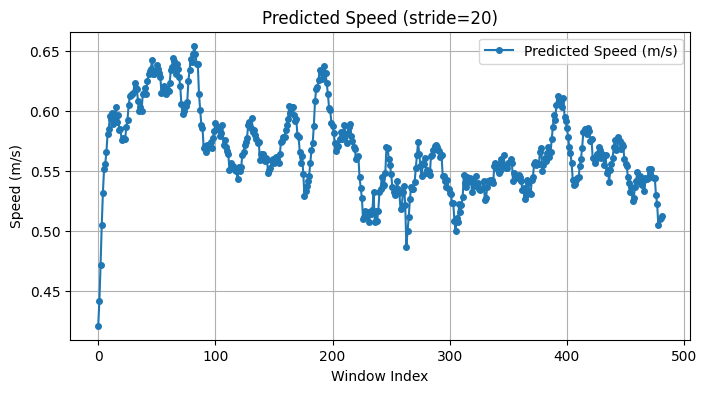

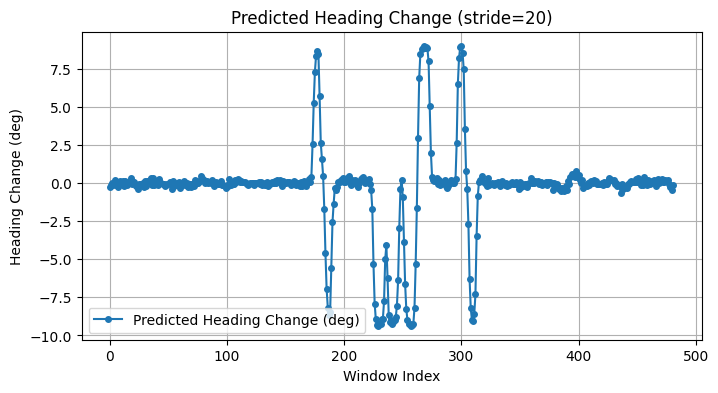

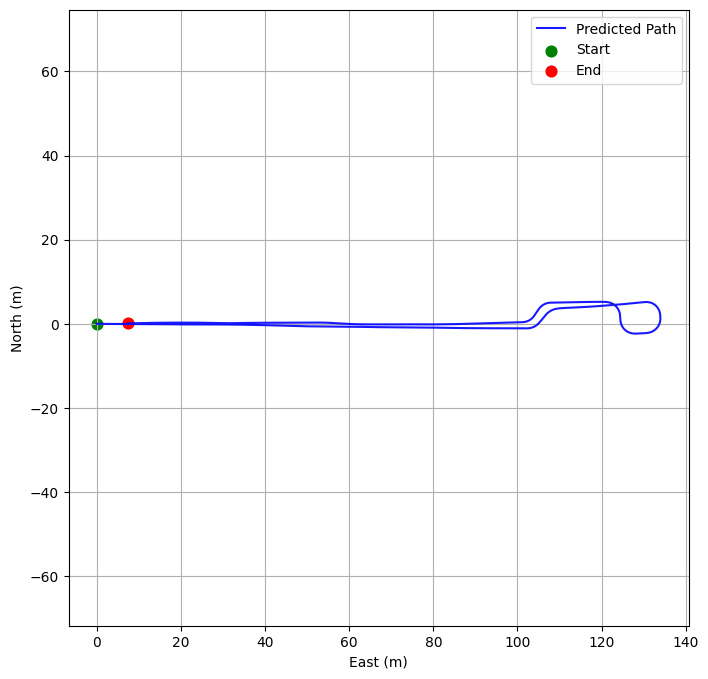

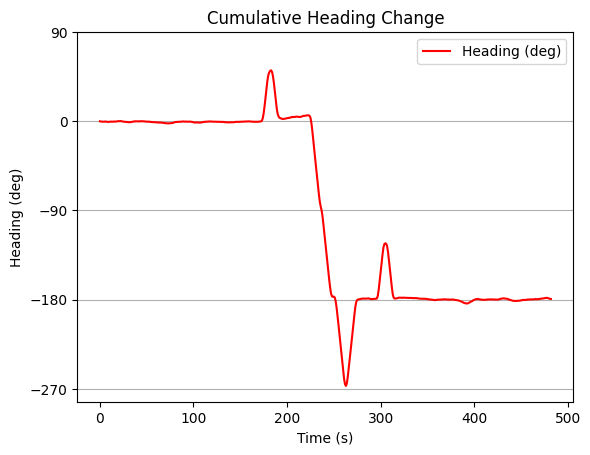

In [1]:
import os
import numpy as np
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.trajectory_predictor import TrajectoryPredictor
import matplotlib.pyplot as plt
import random
import tensorflow as tf

# 시드 값 고정
SEED = 260223
random.seed(SEED)

np.random.seed(SEED)
tf.random.set_seed(SEED)


def main():
    BASE_DIR = os.getcwd()
    window_size = 200

    # model_path = os.path.join(BASE_DIR, 'saved_models', 'model_LSTM_Attention_ws200_20250915_174720.h5') #200, batch_size: 128
    # best = 'ws200_20251022_164209.h5'

    model_path = os.path.join(
        BASE_DIR, "saved_models", "ws200_20260318_235053.h5"
    )  # 200, batch_size: 128
    trainer = ModelTrainer(window_size, num_features=8)
    trainer.load_model(model_path)

    predictor = TrajectoryPredictor(
        trainer.model,
        trainer.x_scaler,
        trainer.y_scaler,
        window_size=window_size,
    )



    test_paths = [
        # 대학 본관 테스트 데이터 
        # ============================================================
        # ============================================================
        # tester1 테스트 데이터 (S22U)
        os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_l01.csv"),
        os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_l02.csv"),
        os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_l03.csv"),
        
        os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_r01.csv"),
        os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_r02.csv"),
        os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_r03.csv"),
        os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_r04.csv"),
        
        # os.path.join(BASE_DIR, "data", "tester1", "test_data", "swing", "test_swing_3loop_l02.csv"),
        # os.path.join(BASE_DIR, "data", "tester1", "test_data", "swing", "test_swing_3loop_r05.csv"),
        
        # os.path.join(BASE_DIR, "data", "tester1", "test_data", "calling", "test_calling_3loop_l02.csv"),
        # os.path.join(BASE_DIR, "data", "tester1", "test_data", "calling", "test_calling_3loop_r02.csv"),
        
        
        #tester1 테스트 데이터 (S20+)
        
        # 공학관 테스트 데이터
        # ============================================================
        # ============================================================
        # tester1 테스트 데이터 (S22U)
        os.path.join(BASE_DIR, "data", "tester1", "test_data2", "test2_looking_01.csv"),
        # os.path.join(BASE_DIR, "data", "tester1", "test_data2", "test2_swing_01.csv"),
        # os.path.join(BASE_DIR, "data", "tester1", "test_data2", "test2_calling_01.csv"),
        
        # tester1 테스트 데이터 (S20+)
        os.path.join(BASE_DIR, "data", "tester1", "test_data2", "test2_looking_01_20+.csv"),
        # os.path.join(BASE_DIR, "data", "tester1", "test_data2", "test2_swing_01_20+.csv"),
        # os.path.join(BASE_DIR, "data", "tester1", "test_data2", "test2_calling_01_20+.csv"),
    ]


    # # 각 테스트 파일에 대해 예측 수행
    for test_path in test_paths:
        if os.path.exists(test_path):
            print(f"\n테스트 파일 처리 중: {os.path.basename(test_path)}")

            # 테스트 데이터 로드 및 전처리
            df_test = DataProcessor.load_and_preprocess_csv_test(test_path, skiprows=50)

            # 예측 경로 시각화
            dist, heading_error = predictor.predict_and_plot_trajectory(df_test, False)
            # predictor.predict_and_plot_trajectory(df_test, True)

            # dists.append(dist)
            # heading_errors.append(heading_error)

        else:
            print(f"테스트 파일을 찾을 수 없습니다: {test_path}")

    # print("\n=== 전체 테스트 결과 ===")
    # print(f"평균 위치 오차: {np.mean(dists):.3f} m")
    # print(f"평균 헤딩 오차: {np.mean(heading_errors):.3f} deg")

if __name__ == "__main__":
    main()